# K-Means Project - Iris Dataset

The goal of this notebook is to use Scikit-Learn's and from scratch **k-means** models to implement a complete machine learning project using Scikit-Learn's Iris dataset.

## 1. Imports

In [15]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans as SKLearnKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from kmeans import KMeans as KMeansScratch

## 2. Load dataset

In [2]:
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)
df['target'] = load_iris().target 

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (150, 5)
Head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Description:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000 

In [5]:
# Prepare the data: keep features
X = df.drop("target", axis=1).values # features
y_true = df["target"].values # target

In [8]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Fit k-means model from scratch

In [11]:
model_scratch = KMeansScratch(K=3, n_init=10, random_state=42)
model_scratch.fit(X_scaled)

Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 6 iterations.


In [13]:
print("Inertia:", model_scratch.inertia_)
print("Silhouette score:", silhouette_score(X_scaled, model_scratch.labels_))

Inertia: 140.0327527742865
Silhouette score: 0.4630420362927047


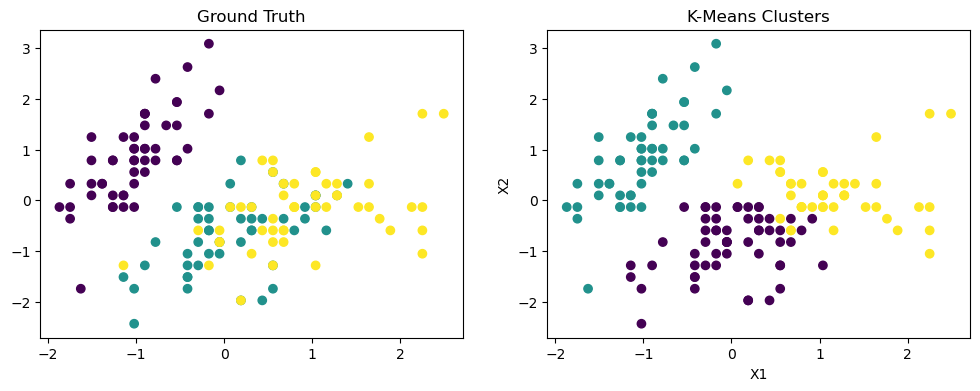

In [19]:
# Visualize the dataset
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='viridis')
ax1.set_title("Ground Truth")

ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model_scratch.labels_, cmap='viridis')
ax2.set_title("K-Means Clusters")

plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

**Observations**:

The two plots are consistent. 

- The left purple cluster (Ground Truth) corresponds well to the right teal cluster (K-Means): setosa, well separated, perfectly recovered.

- The other two species (versicolor and virginica) overlap in the central area: K-Means separates them differently from the true labels, which explains the silhouette score of 0.46.

The colors differ between the two plots because K-Means has no concept of label order: cluster 0 in the scratch plot does not necessarily correspond to label 0 in y_true. This is normal.

## 4. Fit k-means model from Scikit-Learn

In [20]:
model_sklearn = SKLearnKMeans(n_clusters=3, n_init=10, random_state=42)
model_sklearn.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [21]:
print("Inertia:", model_sklearn.inertia_)
print("Silhouette score:", silhouette_score(X_scaled, model_sklearn.labels_))

Inertia: 139.82049635974982
Silhouette score: 0.45994823920518635


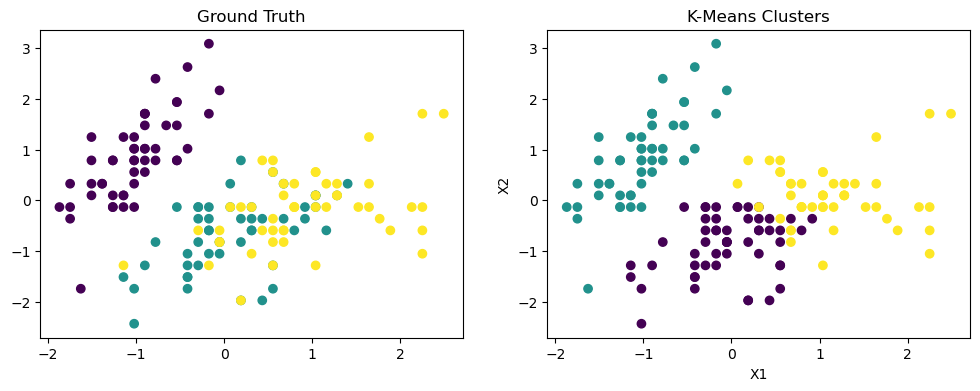

In [22]:
# Visualize the dataset
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='viridis')
ax1.set_title("Ground Truth")

ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model_sklearn.labels_, cmap='viridis')
ax2.set_title("K-Means Clusters")

plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

The **results** from the k-means model implemented from scratch and the sciait-learn model **are similar**. The implementation from scratch was successful.